In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, roc_curve, roc_auc_score, classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
train = pd.read_csv('train.csv')
act_test = pd.read_csv('test.csv')
emp_ids = act_test['employee_id']

In [4]:
train.head(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [6]:
train.isna().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [7]:
train['is_promoted'].value_counts()

is_promoted
0    50140
1     4668
Name: count, dtype: int64

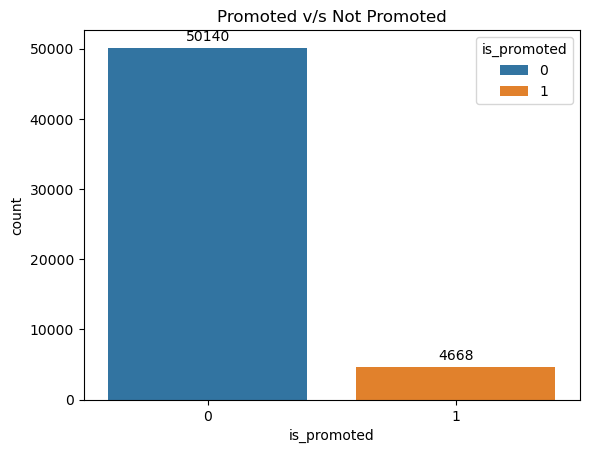

In [8]:
ax = sns.countplot(data=train, x='is_promoted', hue='is_promoted')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Promoted v/s Not Promoted')
plt.show()

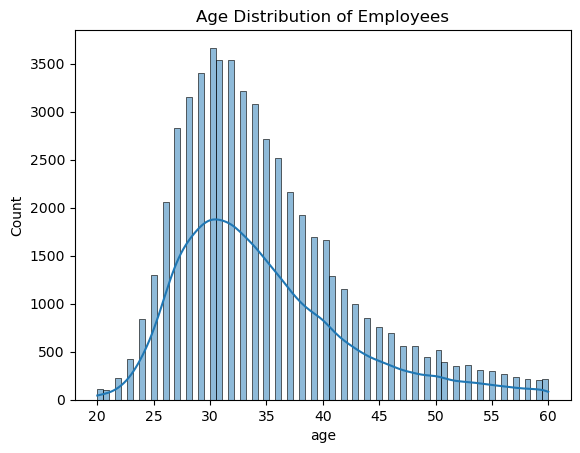

In [9]:
sns.histplot(data = train['age'], kde=True)
plt.title('Age Distribution of Employees')
plt.show()

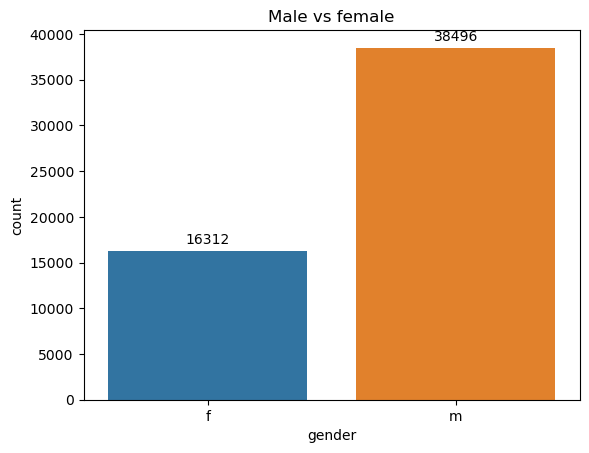

In [10]:
ax = sns.countplot(data=train, x='gender', hue='gender')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Male vs female')
plt.show()

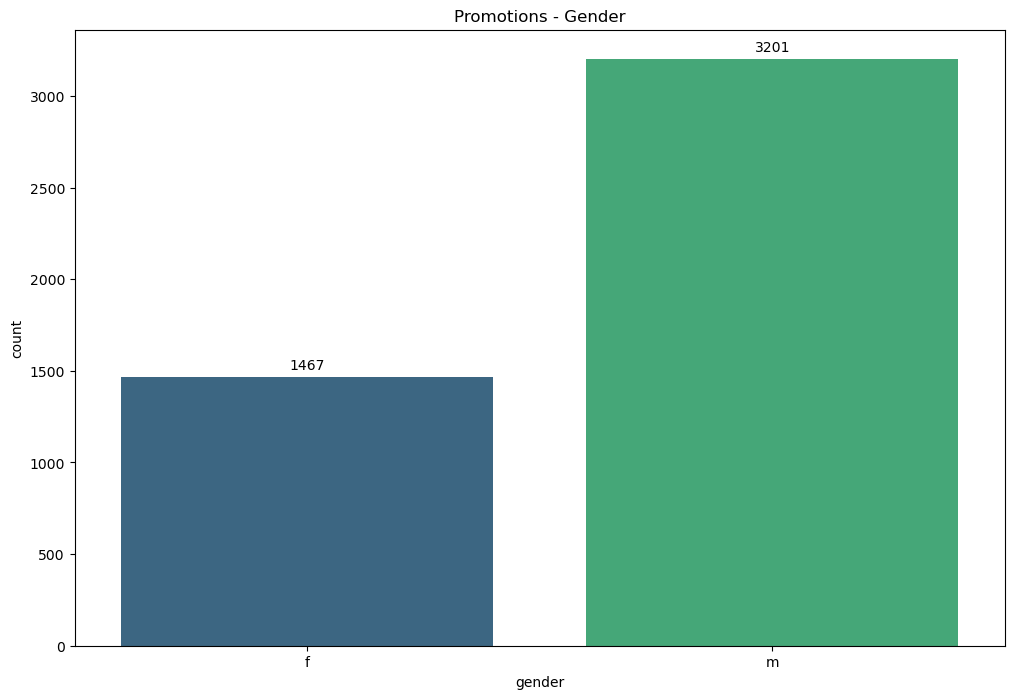

In [11]:
plt.figure(figsize = (12,8))
promoted = train[train['is_promoted']==1]
ax = sns.countplot(data = promoted, x = 'gender', palette = 'viridis')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Promotions - Gender')
plt.show()

In [12]:
num_cols = train.select_dtypes(include = np.number).columns

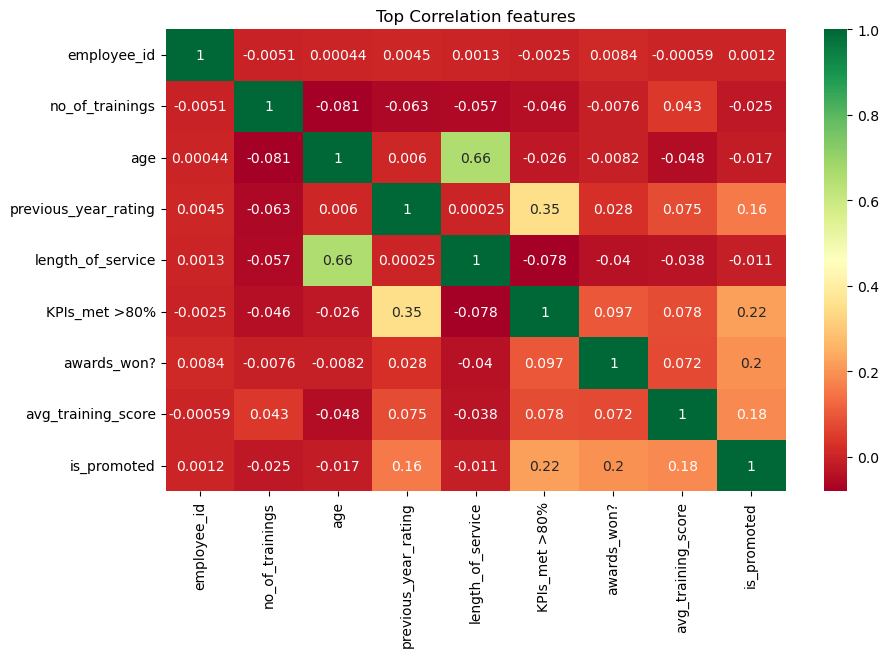

In [13]:
plt.figure(figsize = (10,6))
sns.heatmap(data = train[num_cols].corr(), annot=True,  cmap ='RdYlGn')
plt.title('Top Correlation features')
plt.show()

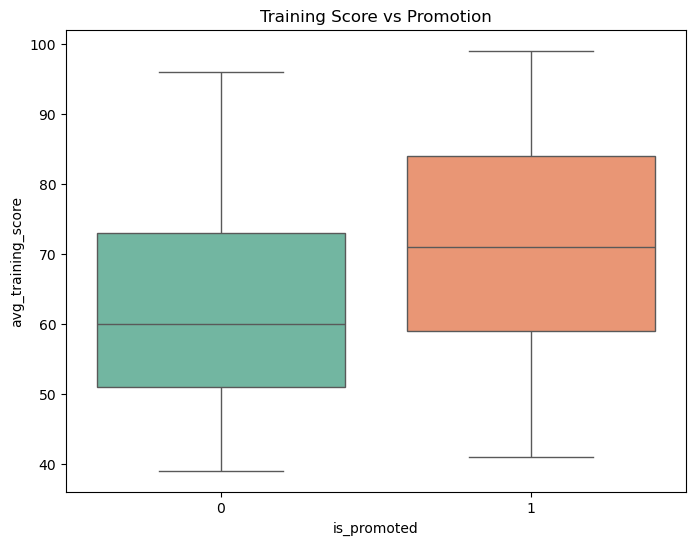

In [14]:
# Does a higher training score lead to promotion?
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_promoted', y='avg_training_score', data=train, palette='Set2')
plt.title('Training Score vs Promotion')
plt.show()

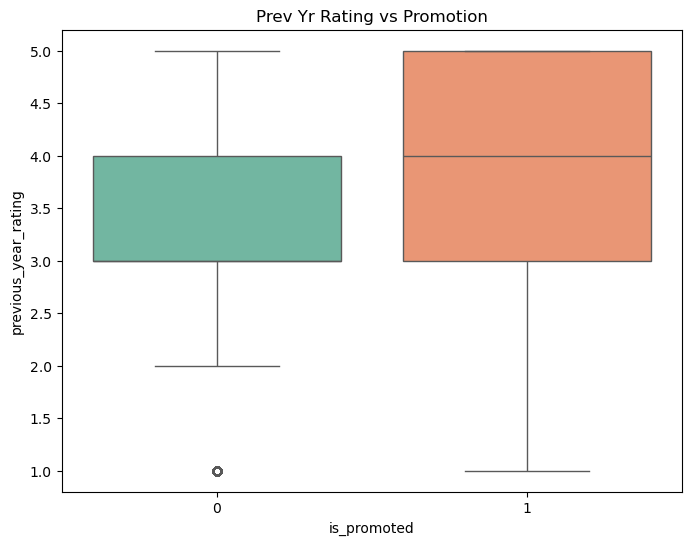

In [15]:
# Does a prev yr rating lead to promotion?
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_promoted', y='previous_year_rating', data=train, palette='Set2')
plt.title('Prev Yr Rating vs Promotion')
plt.show()

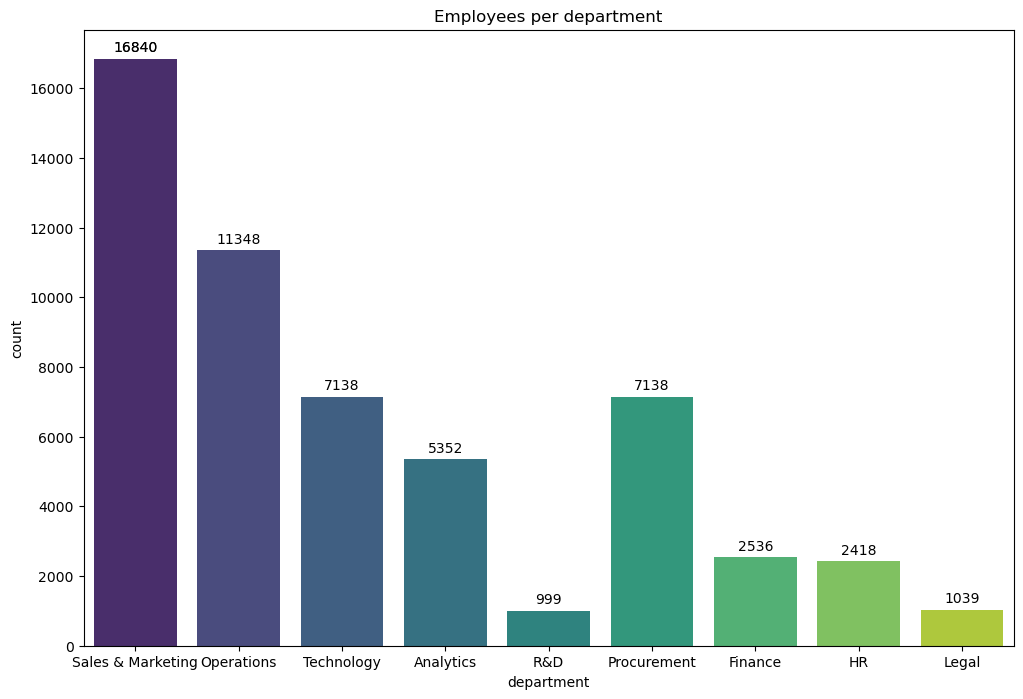

In [16]:
plt.figure(figsize = (12,8))
ax = sns.countplot (data = train, x= train['department'], palette='viridis')
ax.bar_label(ax.containers[0], padding=3)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Employees per department')
plt.show()

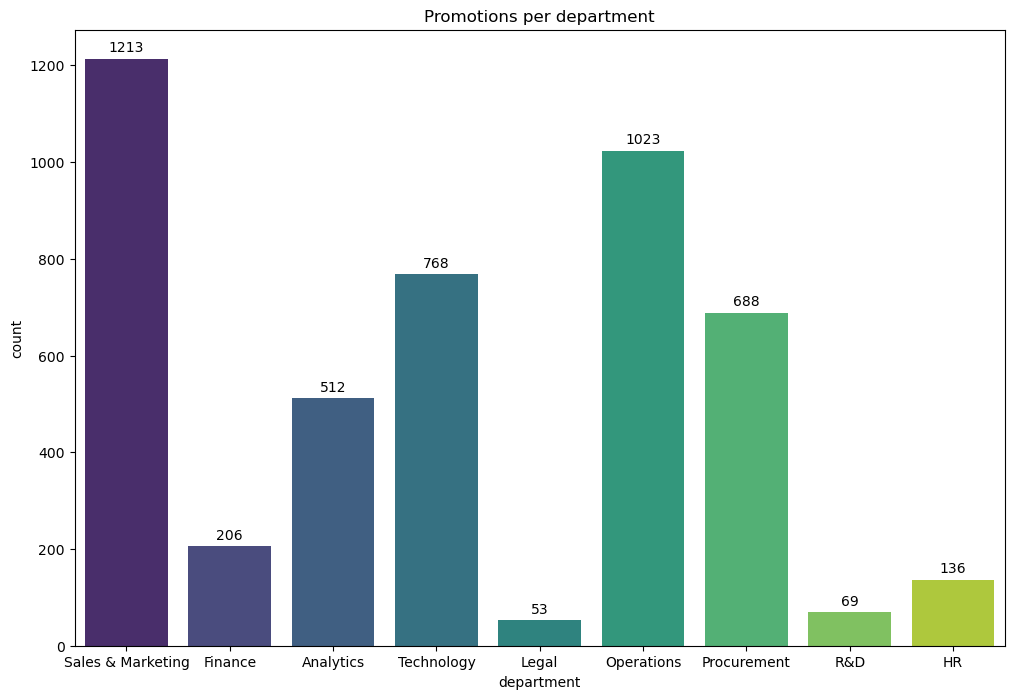

In [17]:
plt.figure(figsize = (12,8))

ax = sns.countplot(data = promoted, x = 'department', palette = 'viridis')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Promotions per department')
plt.show()

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


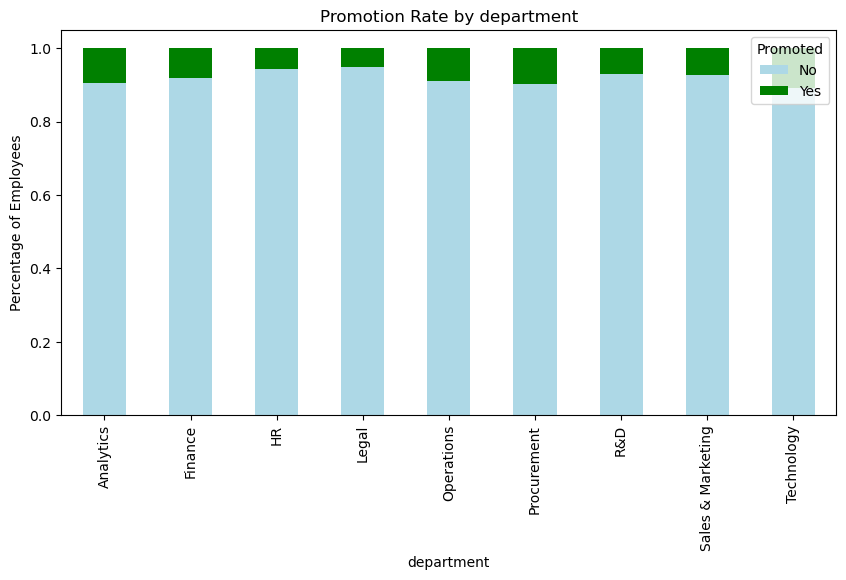

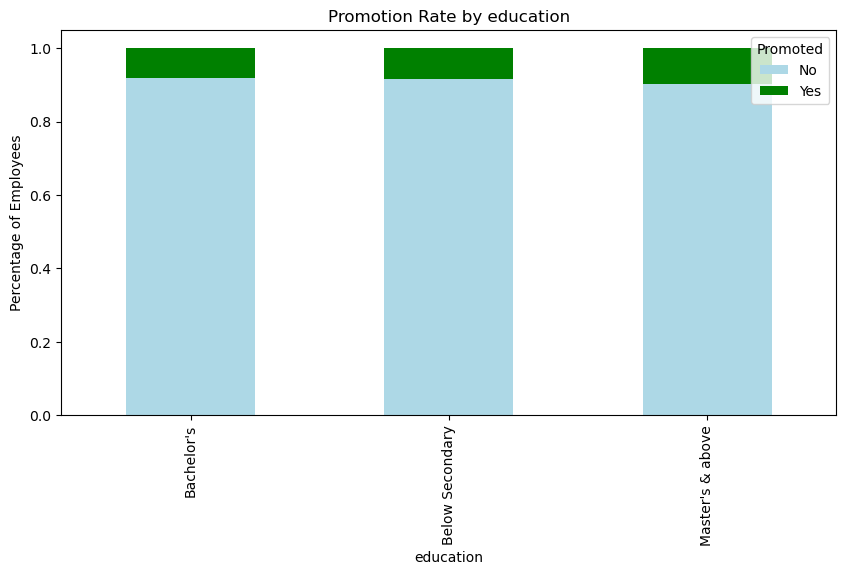

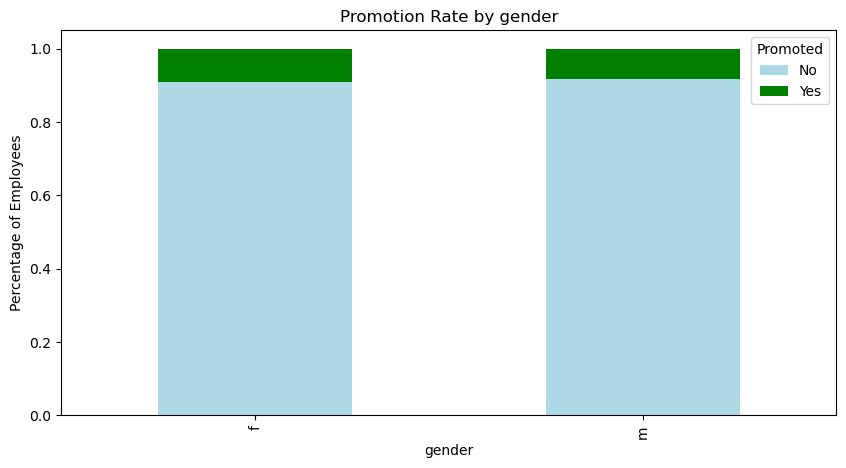

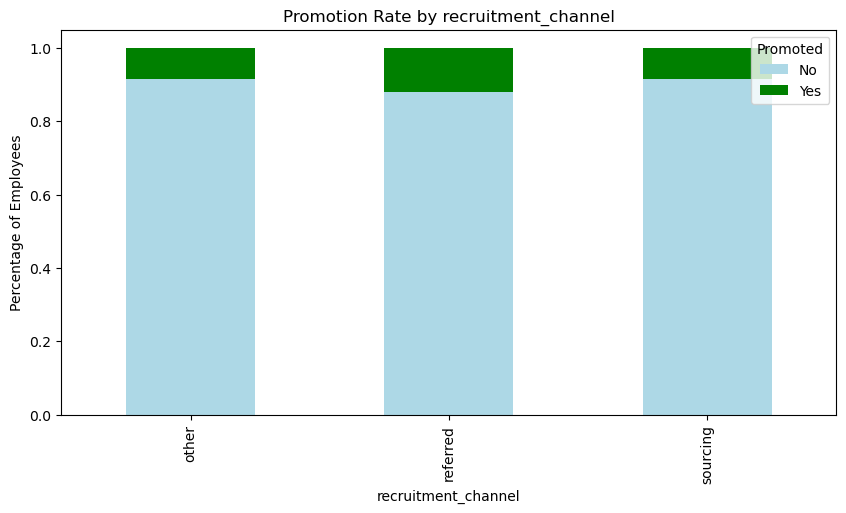

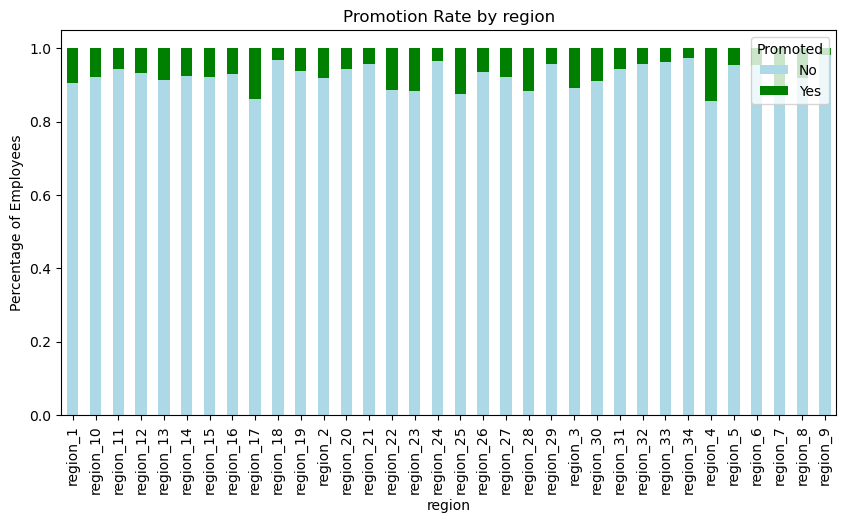

In [19]:
# List of categorical columns to analyze
cat_features = ['department', 'education', 'gender', 'recruitment_channel', 'region']

for col in cat_features:
    # Create a crosstab showing percentages
    ct = pd.crosstab(train[col], train['is_promoted'], normalize='index')
    
    # Plotting
    ct.plot(kind='bar', stacked=True, figsize=(10, 5), color=['lightblue', 'green'])
    plt.title(f'Promotion Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Percentage of Employees')
    plt.legend(title='Promoted', labels=['No', 'Yes'], loc='upper right')
    plt.show()

In [20]:
X  = train.drop('is_promoted', axis=1)
y = train['is_promoted']
train_X, test_X, train_y, test_y = train_test_split(X,y,test_size=0.2, random_state = 42, stratify = y)


In [21]:
# Imputation and Feature engineering
# To avoid data leakage, the "Best Practice" is to calculate your rules using only the training data and then "freeze" those rules to apply them to everything else.
# Rules based ONLY on train_X
rules = {
'edu_mode' : train_X['education'].mode()[0],
'dept_count': train_X['department'].value_counts().to_dict(),
'region_count': train_X['region'].value_counts().to_dict()

}

def data_transform(df, rules):
    data = df.copy()

    data['education'] = data['education'].fillna(rules['edu_mode'])
    data['previous_year_rating'] = data['previous_year_rating'].fillna(0)

    data['total_score'] = data['no_of_trainings'] * data['avg_training_score']
    data['is_high_performer'] = ((data['KPIs_met >80%'] == 1) & (data['awards_won?'] == 1)).astype(int)

    data['education'] = data['education'].map({"Below Secondary": 1, "Bachelor's": 2, "Master's & above": 3})
    data['gender'] = data['gender'].map({'f': 0, 'm': 1})

    data['dept_size'] = data['department'].map(rules['dept_count']).fillna(0)
    data['region_size'] = data['region'].map(rules['region_count']).fillna(0)

    return data.drop(columns=['employee_id', 'department', 'region', 'recruitment_channel'])

In [22]:
ftrain_X = data_transform(train_X, rules)
ftest_X = data_transform(test_X, rules)
factual_test = data_transform(act_test, rules)

In [23]:
ftrain_X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 43846 entries, 25890 to 54230
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   education             43846 non-null  int64  
 1   gender                43846 non-null  int64  
 2   no_of_trainings       43846 non-null  int64  
 3   age                   43846 non-null  int64  
 4   previous_year_rating  43846 non-null  float64
 5   length_of_service     43846 non-null  int64  
 6   KPIs_met >80%         43846 non-null  int64  
 7   awards_won?           43846 non-null  int64  
 8   avg_training_score    43846 non-null  int64  
 9   total_score           43846 non-null  int64  
 10  is_high_performer     43846 non-null  int64  
 11  dept_size             43846 non-null  int64  
 12  region_size           43846 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 4.7 MB


In [24]:
ftest_X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10962 entries, 20086 to 40586
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   education             10962 non-null  int64  
 1   gender                10962 non-null  int64  
 2   no_of_trainings       10962 non-null  int64  
 3   age                   10962 non-null  int64  
 4   previous_year_rating  10962 non-null  float64
 5   length_of_service     10962 non-null  int64  
 6   KPIs_met >80%         10962 non-null  int64  
 7   awards_won?           10962 non-null  int64  
 8   avg_training_score    10962 non-null  int64  
 9   total_score           10962 non-null  int64  
 10  is_high_performer     10962 non-null  int64  
 11  dept_size             10962 non-null  int64  
 12  region_size           10962 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 1.2 MB


In [25]:
factual_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   education             23490 non-null  int64  
 1   gender                23490 non-null  int64  
 2   no_of_trainings       23490 non-null  int64  
 3   age                   23490 non-null  int64  
 4   previous_year_rating  23490 non-null  float64
 5   length_of_service     23490 non-null  int64  
 6   KPIs_met >80%         23490 non-null  int64  
 7   awards_won?           23490 non-null  int64  
 8   avg_training_score    23490 non-null  int64  
 9   total_score           23490 non-null  int64  
 10  is_high_performer     23490 non-null  int64  
 11  dept_size             23490 non-null  int64  
 12  region_size           23490 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 2.3 MB


In [40]:
num_features = ftrain_X.select_dtypes(include = np.number).columns

In [ ]:
#Preprocessing and Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Numerical Transformer
num_transformer = Pipeline (steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

# Preprocessing
preprocessor = ColumnTransformer (transformers = [
    ('num_transform', num_transformer, num_features)
])


In [38]:
def build_model(classifier):
    return Pipeline ([
        ('preprocess', preprocessor),
        ('model', classifier)
    ])

In [ ]:
def run_multi_model_submission(train_x, train_y, test_x, test_y, actual_test_df):
    # Define the 5 Models
    models_to_run = {
        "1_logistic_baseline": build_model(LogisticRegression(max_iter=1000)),
        "2_decision_tree_tuned": build_model(DecisionTreeClassifier(max_depth=10, random_state=42)),
        "3_random_forest": build_model(RandomForestClassifier(n_estimators=200, random_state=42)),
        "4_gradient_boosting": build_model(GradientBoostingClassifier(n_estimators=100, random_state=42)),
        "5_xgboost": build_model(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, use_label_encoder=False, eval_metric='logloss'))
    }

    report = []

    for name, pipeline in models_to_run.items():
        print(f"🚀 Processing: {name}...")
        
        # Fit Model
        pipeline.fit(train_x, train_y)
        
        # Internal Metrics
        val_preds = pipeline.predict(test_x)
        val_f1 = f1_score(test_y, val_preds)
        report.append({"Model": name, "Internal_F1": val_f1})
        
        # Generate Submission File
        actual_preds = pipeline.predict(actual_test_df)
        submission = pd.DataFrame({
            'employee_id': emp_ids,
            'is_promoted': actual_preds
        })
        
        filename = f"submission_{name}.csv"
        submission.to_csv(filename, index=False)
        print(f"✅ Created {filename} | Score: {val_f1:.4f}")

    # Return summary table
    return pd.DataFrame(report).sort_values(by="Internal_F1", ascending=False)

# Execute
ranking = run_multi_model_submission(ftrain_X, train_y, ftest_X, test_y, factual_test)
print("\n--- FINAL RANKINGS ---")
print(ranking)

🚀 Processing: 1_logistic_baseline...
✅ Created submission_1_logistic_baseline.csv | Score: 0.2523
🚀 Processing: 2_decision_tree_tuned...
✅ Created submission_2_decision_tree_tuned.csv | Score: 0.4439
🚀 Processing: 3_random_forest...
✅ Created submission_3_random_forest.csv | Score: 0.4553
🚀 Processing: 4_gradient_boosting...
✅ Created submission_4_gradient_boosting.csv | Score: 0.4319
🚀 Processing: 5_xgboost_winner...
✅ Created submission_5_xgboost_winner.csv | Score: 0.5032

--- FINAL RANKINGS ---
                   Model  Internal_F1
4       5_xgboost_winner     0.503155
2        3_random_forest     0.455322
1  2_decision_tree_tuned     0.443910
3    4_gradient_boosting     0.431894
0    1_logistic_baseline     0.252285
